In [1]:
import EFC_learningfMRI.util as util
import EFC_learningfMRI.globals as gl
import os
import numpy as np
import PcmPy as pcm
import matplotlib.pyplot as plt
import EFC_learningfMRI.vis as vis
import pandas as pd
import seaborn as sb

base directory found: /cifs/diedrichsen/data/Chord_exp/EFC_learningfMRI
Atlas directory found: atlases
figure directory found: figures/


In [2]:
# pick one example participant and list the chords they trained
sn     = 102                           # example participant
chords = util.get_trained_and_untrained(sn)    # the 4 trained chords, then the 4 untrained ones
path   = os.path.join(gl.baseDir, gl.pcmDir, f'subj{sn}')

hue_order = ['trained', 'untrained']
palette   = ['red', 'blue']

print(f'subj{sn}: trained {chords[:4]}, untrained {chords[4:]}')

subj102: trained ['22911', '11911', '21291', '12291'], untrained ['21911', '92122', '91211', '12129']


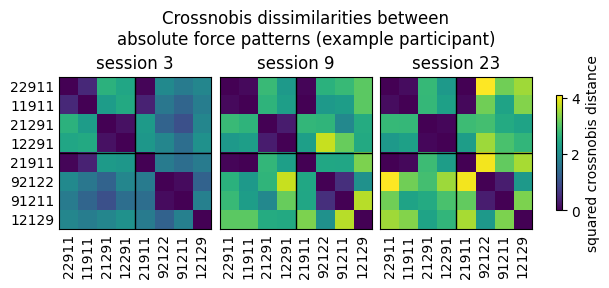

In [3]:
# example participant: dissimilarities between average absolute force patterns, one matrix per session

metric = 'abs'

D = []
for sess in gl.sessions:
    G = np.load(os.path.join(path, f'G_obs_raw.within_session.{sess}.force.{metric}.npy'))
    D.append(pcm.G_to_dist(G))
D = np.array(D)

fig, axs = plt.subplots(1, len(D), figsize=(6, 2.7), constrained_layout=True)
vis.plot_mat_sess(fig, axs, D, labels=chords, cbar_label='squared crossnobis distance')
fig.suptitle(f'Crossnobis dissimilarities between\nabsolute force patterns (example participant)')
plt.show()

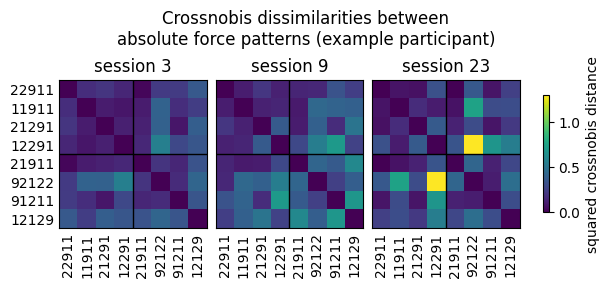

In [4]:
# example participant: dissimilarities between absolute force derivative patterns, one matrix per session

metric = 'der'

D = []
for sess in gl.sessions:
    G = np.load(os.path.join(path, f'G_obs_raw.within_session.{sess}.force.{metric}.npy'))
    D.append(pcm.G_to_dist(G))
D = np.array(D)

fig, axs = plt.subplots(1, len(D), figsize=(6, 2.7), constrained_layout=True)
vis.plot_mat_sess(fig, axs, D, labels=chords, cbar_label='squared crossnobis distance')
fig.suptitle(f'Crossnobis dissimilarities between\nabsolute force patterns (example participant)')
plt.show()

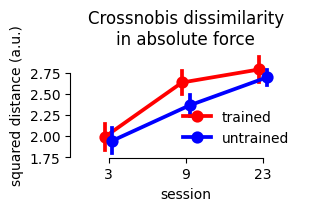

In [9]:
dist = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, 'dissimilarity.within_session.force.tsv'), sep='\t')
dist = dist[dist.chord.isin(hue_order)]
dist_g = dist.groupby(['sn', 'session', 'chord', 'metric']).mean(numeric_only=True).reset_index()

fig, ax = plt.subplots(figsize=(3, 2), constrained_layout=True)

sb.pointplot(ax=ax, data=dist_g[dist_g.metric=='abs'], x='session', y='crossnobis', hue='chord', hue_order=hue_order, palette=palette, errorbar='se', dodge=.1)
sb.despine(ax=axs[0], trim=True)
ax.set_ylabel('squared distance (a.u.)')
ax.legend(frameon=False, loc='lower right')
ax.set_xlabel('session')
sb.despine(ax=ax, trim=True)

ax.set_title('Crossnobis dissimilarity\nin absolute force')

plt.show()

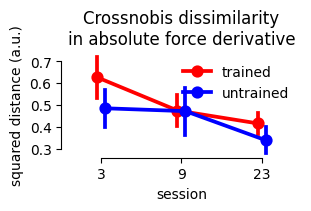

In [10]:
fig, ax = plt.subplots(figsize=(3, 2), constrained_layout=True)

sb.pointplot(ax=ax, data=dist_g[dist_g.metric=='der'], x='session', y='crossnobis', hue='chord', hue_order=hue_order, palette=palette, errorbar='se', dodge=.1)
sb.despine(ax=axs[0], trim=True)
ax.set_ylabel('squared distance (a.u.)')
ax.legend(frameon=False, loc='upper right')
ax.set_xlabel('session')
sb.despine(ax=ax, trim=True)

ax.set_title('Crossnobis dissimilarity\nin absolute force derivative')

plt.show()